# Cross-Reference Analysis: All Enforce Knowledge Configs

This notebook compares LLM responses across all three enforce_knowledge configurations to answer:
1. **Does more data help?** - Compare ranking accuracy as N_SAMPLES and N_LOCAL increase
2. **XAI impact:** - Does Phase 2 (with SHAP+LIME) consistently improve over Phase 1?
3. **Model differences:** - Which models benefit most from XAI injection?
4. **Diminishing returns:** - Is there a point where adding more samples/local explanations stops helping?

## Configurations compared
| Config | N_SAMPLES | N_LOCAL |
|--------|-----------|--------|
| 1      | 10        | 10     |
| 2      | 20        | 15     |
| 3      | 40        | 25     |

In [1]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Markdown, HTML
import sys
sys.path.append('.')
from validation_helpers import (
    compute_ground_truth,
    extract_all_rankings,
    extract_shap_values,
    score_shap_citations,
    check_user_agent_overvaluation,
    check_fabricated_percentages,
    ranking_accuracy,
    ranking_top3_set_overlap,
)

In [8]:
# Load all three config results
configs = {
    '10_10': 'resultados_enforce_knowledge_samples_10_local_10.json',
    '20_15': 'resultados_enforce_knowledge_samples_20_local_15.json',
    '40_25': 'resultados_enforce_knowledge_samples_40_local_25.json',
}

all_data = {}
for config_key, filename in configs.items():
    with open(filename, 'r', encoding='utf-8') as f:
        all_data[config_key] = json.load(f)
    print(f"Loaded {config_key}: {len(all_data[config_key])} models")

Loaded 10_10: 4 models
Loaded 20_15: 4 models
Loaded 40_25: 4 models


In [9]:
# Compute ground truth (shared across all configs)
gt = compute_ground_truth('../Network_logs.csv')

print("=== Ground Truth SHAP Rankings (Top-3 per class) ===")
for cls_name, ranking in gt['shap_rankings'].items():
    print(f"{cls_name}: {' > '.join(ranking[:3])}")

=== Ground Truth SHAP Rankings (Top-3 per class) ===
BotAttack: Port > Status > Payload_Size
Normal: Port > Status > Payload_Size
PortScan: Payload_Size > Status > Port


In [10]:
# Validate all configs and models
def validate_config(config_key, results, gt):
    """Validate all models in a config, return list of score dicts."""
    scores = []
    
    for model_name, model_data in results.items():
        for phase_key, phase_label in [
            ('phase1_without_xai', 'Phase 1'),
            ('phase2_with_xai', 'Phase 2')
        ]:
            if phase_key not in model_data:
                continue
            
            text = model_data[phase_key]
            predicted_rankings = extract_all_rankings(text, gt['class_names'])
            
            # Ranking accuracy
            correct, total, _ = ranking_accuracy(predicted_rankings, gt['shap_rankings'], gt['class_names'])
            ranking_acc = correct / total if total > 0 else 0
            
            # Set overlap
            overlap_correct, overlap_total = ranking_top3_set_overlap(predicted_rankings, gt['shap_rankings'], gt['class_names'])
            set_overlap = overlap_correct / overlap_total if overlap_total > 0 else 0
            
            # User_Agent overvaluation
            ua_hits = check_user_agent_overvaluation(text)
            
            # Fabricated percentages (Phase 1 only)
            fab_pct = check_fabricated_percentages(text) if phase_key == 'phase1_without_xai' else []
            
            # SHAP citations (Phase 2 only)
            if phase_key == 'phase2_with_xai':
                cited_shap = extract_shap_values(text, gt['class_names'])
                shap_checks = score_shap_citations(cited_shap, gt['shap_ground_truth'], gt['class_names'])
                n_exact = sum(1 for c in shap_checks if c['status'] == 'EXACT')
                n_close = sum(1 for c in shap_checks if c['status'] == 'CLOSE')
                n_off = sum(1 for c in shap_checks if c['status'] == 'OFF')
            else:
                n_exact = n_close = n_off = None
            
            scores.append({
                'config': config_key,
                'n_samples': int(config_key.split('_')[0]),
                'n_local': int(config_key.split('_')[1]),
                'model': model_name,
                'phase': phase_label,
                'phase_key': phase_key,
                'ranking_accuracy': ranking_acc,
                'set_overlap': set_overlap,
                'user_agent_overvaluation': len(ua_hits),
                'fabricated_percentages': len(fab_pct),
                'shap_exact': n_exact,
                'shap_close': n_close,
                'shap_off': n_off,
                'text_length': len(text),
            })
    
    return scores

# Validate all configs
all_scores = []
for config_key, results in all_data.items():
    all_scores.extend(validate_config(config_key, results, gt))

print(f"Validated {len(all_scores)} model/phase combinations")

Validated 24 model/phase combinations


## Summary Table - All Configs

In [11]:
summary_df = pd.DataFrame(all_scores)
display(summary_df)

,config,n_samples,n_local,model,phase,phase_key,ranking_accuracy,set_overlap,user_agent_overvaluation,fabricated_percentages,shap_exact,shap_close,shap_off,text_length
0,10_10,10,10,glm-4.7-flash:latest,Phase 1,phase1_without_xai,0.000000,0.000000,2,0,NaN,NaN,NaN,6332
1,10_10,10,10,glm-4.7-flash:latest,Phase 2,phase2_with_xai,0.000000,0.333333,0,0,0.0,0.0,0.0,4974
2,10_10,10,10,qwen3:14b,Phase 1,phase1_without_xai,0.111111,0.666667,1,0,NaN,NaN,NaN,6113
3,10_10,10,10,qwen3:14b,Phase 2,phase2_with_xai,0.000000,0.000000,0,0,2.0,1.0,6.0,5939
4,10_10,10,10,gpt-oss:20b,Phase 1,phase1_without_xai,0.111111,0.333333,0,0,NaN,NaN,NaN,11157
5,10_10,10,10,gpt-oss:20b,Phase 2,phase2_with_xai,0.777778,1.000000,0,0,0.0,0.0,0.0,8029
6,10_10,10,10,qwen3:30b,Phase 1,phase1_without_xai,0.000000,0.000000,0,0,NaN,NaN,NaN,6075
7,10_10,10,10,qwen3:30b,Phase 2,phase2_with_xai,0.000000,0.000000,0,0,0.0,0.0,0.0,0
8,20_15,20,15,glm-4.7-flash:latest,Phase 1,phase1_without_xai,0.111111,0.333333,0,0,NaN,NaN,NaN,5520
9,20_15,20,15,glm-4.7-flash:latest,Phase 2,phase2_with_xai,0.000000,0.000000,0,0,0.0,0.0,0.0,7145


## Analysis 1: Does more data improve ranking accuracy?

=== Ranking Accuracy by Config (N_SAMPLES, N_LOCAL) ===


,config,phase,mean,std,count,config_order
0,10_10,Phase 1,0.055556,0.064150,4,NaN
1,10_10,Phase 2,0.194444,0.388889,4,NaN
2,20_15,Phase 1,0.027778,0.055556,4,NaN
3,20_15,Phase 2,0.000000,0.000000,4,NaN
4,40_25,Phase 1,0.055556,0.064150,4,NaN
5,40_25,Phase 2,0.055556,0.111111,4,NaN


IndexError: index 0 is out of bounds for axis 0 with size 0

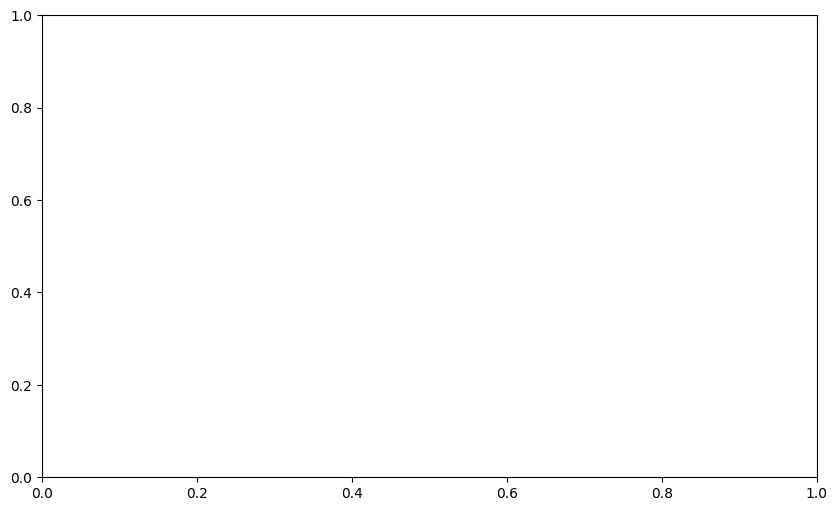

In [12]:
# Group by config and phase, compute mean ranking accuracy
config_summary = summary_df.groupby(['config', 'phase'])['ranking_accuracy'].agg(['mean', 'std', 'count']).reset_index()
config_summary['config_order'] = config_summary['config'].map({'10s_10l': 1, '20s_15l': 2, '40s_25l': 3})
config_summary = config_summary.sort_values('config_order')

print("=== Ranking Accuracy by Config (N_SAMPLES, N_LOCAL) ===")
display(config_summary)

# Plot (if matplotlib available)
try:
    import matplotlib.pyplot as plt
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    configs_ordered = ['10s_10l', '20s_15l', '40s_25l']
    x = np.arange(len(configs_ordered))
    width = 0.35
    
    phase1_means = [config_summary[(config_summary['config']==c) & (config_summary['phase']=='Phase 1')]['mean'].values[0] for c in configs_ordered]
    phase2_means = [config_summary[(config_summary['config']==c) & (config_summary['phase']=='Phase 2')]['mean'].values[0] for c in configs_ordered]
    
    ax.bar(x - width/2, phase1_means, width, label='Phase 1 (No XAI)', capsize=4)
    ax.bar(x + width/2, phase2_means, width, label='Phase 2 (With XAI)', capsize=4)
    ax.set_ylabel('Ranking Accuracy')
    ax.set_xlabel('Config')
    ax.set_title('Ranking Accuracy vs Data Volume')
    ax.set_xticks(x)
    ax.set_xticklabels(['10s+10l', '20s+15l', '40s+25l'])
    ax.legend()
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib not available, skipping plot")

## Analysis 2: XAI Impact (Phase 2 vs Phase 1)

In [13]:
# Compute Phase 2 - Phase 1 delta per model/config
phase_delta = []
for config_key in ['10s_10l', '20s_15l', '40s_25l']:
    for model_name in summary_df['model'].unique():
        p1 = summary_df[(summary_df['config']==config_key) & (summary_df['phase_key']=='phase1_without_xai') & (summary_df['model']==model_name)]['ranking_accuracy'].values
        p2 = summary_df[(summary_df['config']==config_key) & (summary_df['phase_key']=='phase2_with_xai') & (summary_df['model']==model_name)]['ranking_accuracy'].values
        if len(p1) > 0 and len(p2) > 0:
            phase_delta.append({
                'config': config_key,
                'model': model_name,
                'phase1_acc': p1[0],
                'phase2_acc': p2[0],
                'delta': p2[0] - p1[0],
            })

delta_df = pd.DataFrame(phase_delta)
print("=== XAI Impact (Phase 2 - Phase 1 delta) ===")
display(delta_df)

# Summary: how many improved?
improved = (delta_df['delta'] > 0).sum()
unchanged = (delta_df['delta'] == 0).sum()
worse = (delta_df['delta'] < 0).sum()
total = len(delta_df)

print(f"\nXAI Impact Summary:")
print(f"  Improved: {improved}/{total} ({improved/total:.1%})")
print(f"  Unchanged: {unchanged}/{total} ({unchanged/total:.1%})")
print(f"  Worse: {worse}/{total} ({worse/total:.1%})")
print(f"  Mean delta: {delta_df['delta'].mean():.3f}")

=== XAI Impact (Phase 2 - Phase 1 delta) ===


""


KeyError: 'delta'

## Analysis 3: User_Agent Overvaluation Across Configs

In [14]:
# User_Agent overvaluation by config and phase
ua_summary = summary_df.groupby(['config', 'phase'])['user_agent_overvaluation'].agg(['mean', 'sum', 'count']).reset_index()
ua_summary['config_order'] = ua_summary['config'].map({'10s_10l': 1, '20s_15l': 2, '40s_25l': 3})
ua_summary = ua_summary.sort_values('config_order')

print("=== User_Agent Overvaluation by Config ===")
display(ua_summary)

# Key insight: UA overvaluation should DECREASE in Phase 2 (XAI shows UA is unimportant)
print("\nKey question: Does XAI injection reduce User_Agent overvaluation?")

=== User_Agent Overvaluation by Config ===


,config,phase,mean,sum,count,config_order
0,10_10,Phase 1,0.75,3,4,NaN
1,10_10,Phase 2,0.00,0,4,NaN
2,20_15,Phase 1,2.25,9,4,NaN
3,20_15,Phase 2,0.25,1,4,NaN
4,40_25,Phase 1,1.00,4,4,NaN
5,40_25,Phase 2,1.25,5,4,NaN



Key question: Does XAI injection reduce User_Agent overvaluation?


## Analysis 4: SHAP Citation Accuracy (Phase 2 only)

In [15]:
# SHAP citation accuracy by config
phase2_only = summary_df[summary_df['phase_key'] == 'phase2_with_xai']
shap_summary = phase2_only.groupby('config')[['shap_exact', 'shap_close', 'shap_off']].agg(['sum', 'mean']).reset_index()
shap_summary['config_order'] = shap_summary['config'].map({'10s_10l': 1, '20s_15l': 2, '40s_25l': 3})
shap_summary = shap_summary.sort_values('config_order')

print("=== SHAP Citation Accuracy (Phase 2 only) ===")
display(shap_summary)

# Does more local data (N_LOCAL) improve SHAP citations?
# N_LOCAL: 10 -> 15 -> 25

=== SHAP Citation Accuracy (Phase 2 only) ===


config shap_exact       shap_close       shap_off       config_order
                sum  mean        sum  mean      sum  mean             
0  10_10        2.0  0.50        1.0  0.25      6.0  1.50          NaN
1  20_15        5.0  1.25       11.0  2.75     11.0  2.75          NaN
2  40_25        4.0  1.00        9.0  2.25      5.0  1.25          NaN

## Analysis 5: Per-Model Breakdown

In [ ]:
# Ranking accuracy by model across configs
model_summary = summary_df.groupby(['model', 'config', 'phase'])['ranking_accuracy'].mean().unstack('phase')
print("=== Ranking Accuracy by Model and Config ===")
display(model_summary)

# Check if qwen3:30b fails on Phase 2 (known issue from CLAUDE.md)
qwen30b_phase2 = summary_df[(summary_df['model']=='qwen3:30b') & (summary_df['phase_key']=='phase2_with_xai')]
print(f"\nqwen3:30b Phase 2 responses: {len(qwen30b_phase2)} (expected 3, one per config)")
if len(qwen30b_phase2) < 3:
    missing_configs = set(['10s_10l', '20s_15l', '40s_25l']) - set(qwen30b_phase2['config'].values)
    print(f"  Missing configs: {missing_configs}")

## Analysis 6: Text Length vs Config

In [ ]:
# Does more data produce longer responses?
length_summary = summary_df.groupby(['config', 'phase'])['text_length'].agg(['mean', 'std', 'min', 'max']).reset_index()
length_summary['config_order'] = length_summary['config'].map({'10s_10l': 1, '20s_15l': 2, '40s_25l': 3})
length_summary = length_summary.sort_values('config_order')

print("=== Text Length by Config ===")
display(length_summary)

# Check for truncation (max_tokens_analysis: 8192 for medium, 16384 for large)
print("\nNote: Medium models (glm-4.7-flash, qwen3:14b, gpt-oss:20b) have max_tokens=8192")
print("      Large model (qwen3:30b) has max_tokens=16384")
print("      Responses near these limits may be truncated")

## Conclusions

In [16]:
# Final summary for human validation decision
print("="*60)
print("SUMMARY FOR HUMAN VALIDATION")
print("="*60)

# Overall ranking accuracy
overall_acc = summary_df['ranking_accuracy'].mean()
print(f"\n1. Overall ranking accuracy: {overall_acc:.1%}")
print(f"   (Chance baseline: 1/7 features in top-3 = ~14% per position)")

# XAI improvement rate
improved_rate = (delta_df['delta'] > 0).sum() / len(delta_df)
print(f"\n2. XAI improves ranking accuracy in {improved_rate:.1%} of cases")
print(f"   Mean improvement: {delta_df['delta'].mean():.3f}")

# User_Agent overvaluation
ua_rate = summary_df['user_agent_overvaluation'].sum() / len(summary_df)
print(f"\n3. User_Agent overvaluation: {ua_rate:.2f} hits per response")
print(f"   (Ground truth: User_Agent SHAP < 0.006, should NOT be in top-3)")

# SHAP citation accuracy
total_citations = phase2_only['shap_exact'].sum() + phase2_only['shap_close'].sum() + phase2_only['shap_off'].sum()
exact_rate = phase2_only['shap_exact'].sum() / total_citations if total_citations > 0 else 0
print(f"\n4. SHAP citation accuracy: {exact_rate:.1%} exact matches")

# Config trend
trend = "unclear" 
if config_summary.iloc[0]['mean'] < config_summary.iloc[2]['mean']:
    trend = "improves with more data"
elif config_summary.iloc[0]['mean'] > config_summary.iloc[2]['mean']:
    trend = "decreases with more data (possible overload)"
else:
    trend = "stable across configs"
print(f"\n5. Data volume effect: {trend}")

print("\n" + "="*60)
print("Recommendation: Check individual responses in per-config notebooks")
print("                before proceeding to full human validation.")
print("="*60)

SUMMARY FOR HUMAN VALIDATION

1. Overall ranking accuracy: 6.5%
   (Chance baseline: 1/7 features in top-3 = ~14% per position)


KeyError: 'delta'